<a href="https://colab.research.google.com/github/anjali-148/FL_Based_Intrusion_Detection_System/blob/main/FL_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gdown
import gdown
import pandas as pd

# Your CSV files from Drive
train_file_id = "1w6i_ZDWzyWPQvbWmLjq12qHN0ZgQJo5T"
test_file_id  = "1FHGsG0Dgf9Fx2TNMzu9phbcx7qixyeoP"

train_url = f"https://drive.google.com/uc?id={train_file_id}"
test_url  = f"https://drive.google.com/uc?id={test_file_id}"

train_df = pd.read_csv(train_url)
test_df  = pd.read_csv(test_url)

train_df.head()


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
# ==========================================================
# Intrusion Detection System using UNSW-NB15 Dataset
# Models:
#   1. Logistic Regression
#   2. Random Forest
#   3. CNN
# ==========================================================


# ==========================================================
# 1. Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

from imblearn.over_sampling import SMOTE

In [ ]:

# ==========================================================

# Remove unnecessary column
train_df = train_df.drop(columns=['id'], errors='ignore')
test_df  = test_df.drop(columns=['id'], errors='ignore')


# ==========================================================
# 5. Encode Categorical Features
# ==========================================================

categorical_cols = ['proto', 'service', 'state']

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    train_df[col] = le.fit_transform(train_df[col])

    encoders[col] = le

    # Handle unseen labels in test dataset
    test_df[col] = test_df[col].map(
        lambda s: le.transform([s])[0] if s in le.classes_ else -1
    )



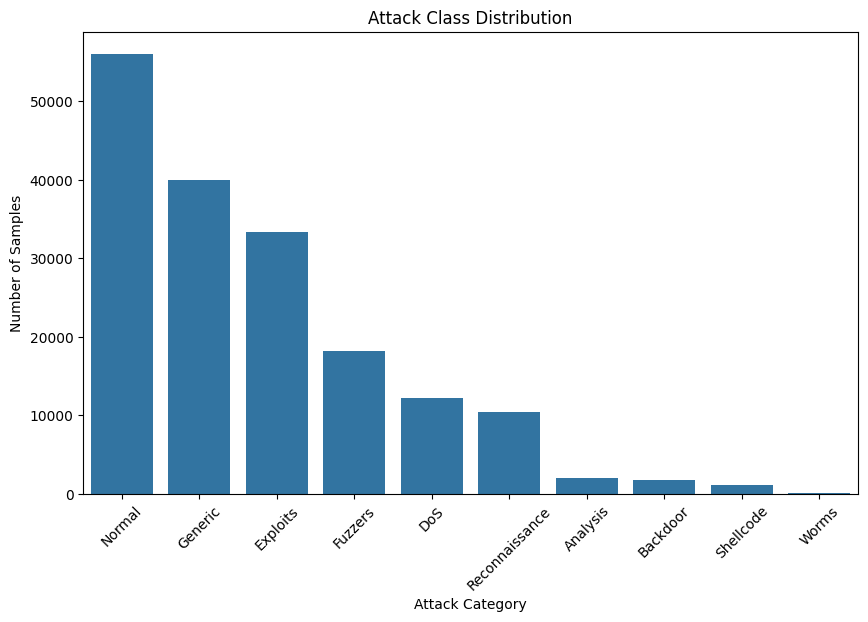

In [ ]:

# ==========================================================
# 6. Handle Missing Values
# ==========================================================

train_df = train_df.fillna(train_df.mean(numeric_only=True))
test_df  = test_df.fillna(test_df.mean(numeric_only=True))
# =========================================
# Attack Class Distribution
# =========================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=train_df,
    x='attack_cat',
    order=train_df['attack_cat'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Attack Class Distribution")

plt.xlabel("Attack Category")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
# ==========================================================
# 7. Remove Attack Category Column
# ==========================================================

train_df = train_df.drop(columns=['attack_cat'], errors='ignore')
test_df  = test_df.drop(columns=['attack_cat'], errors='ignore')


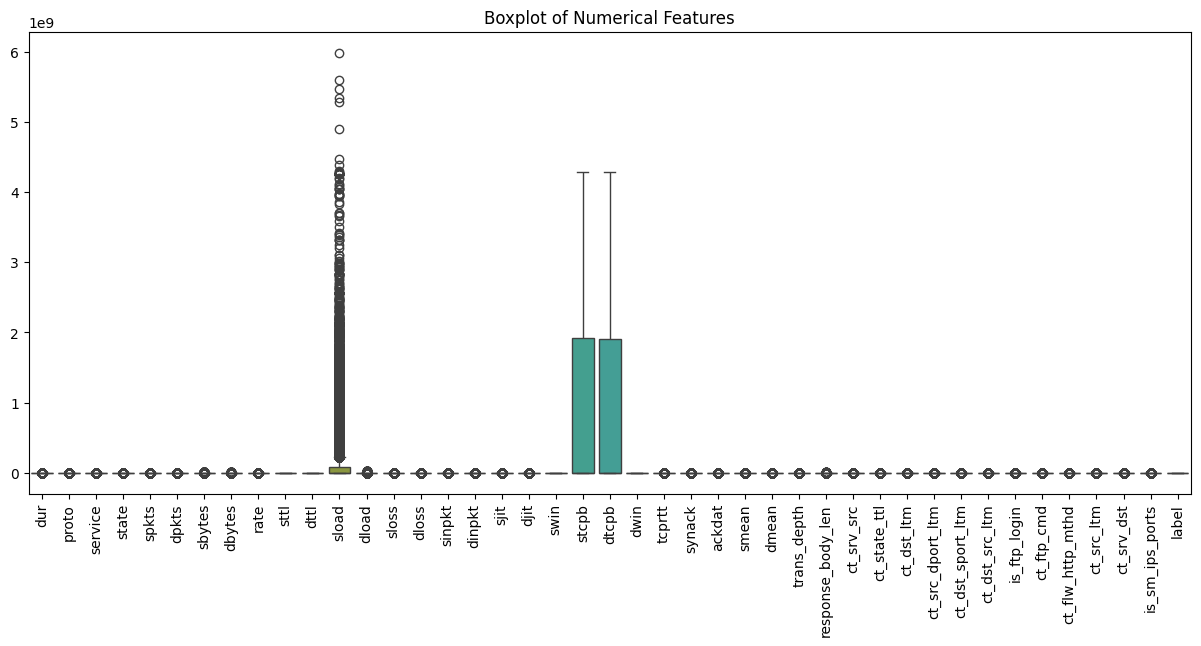

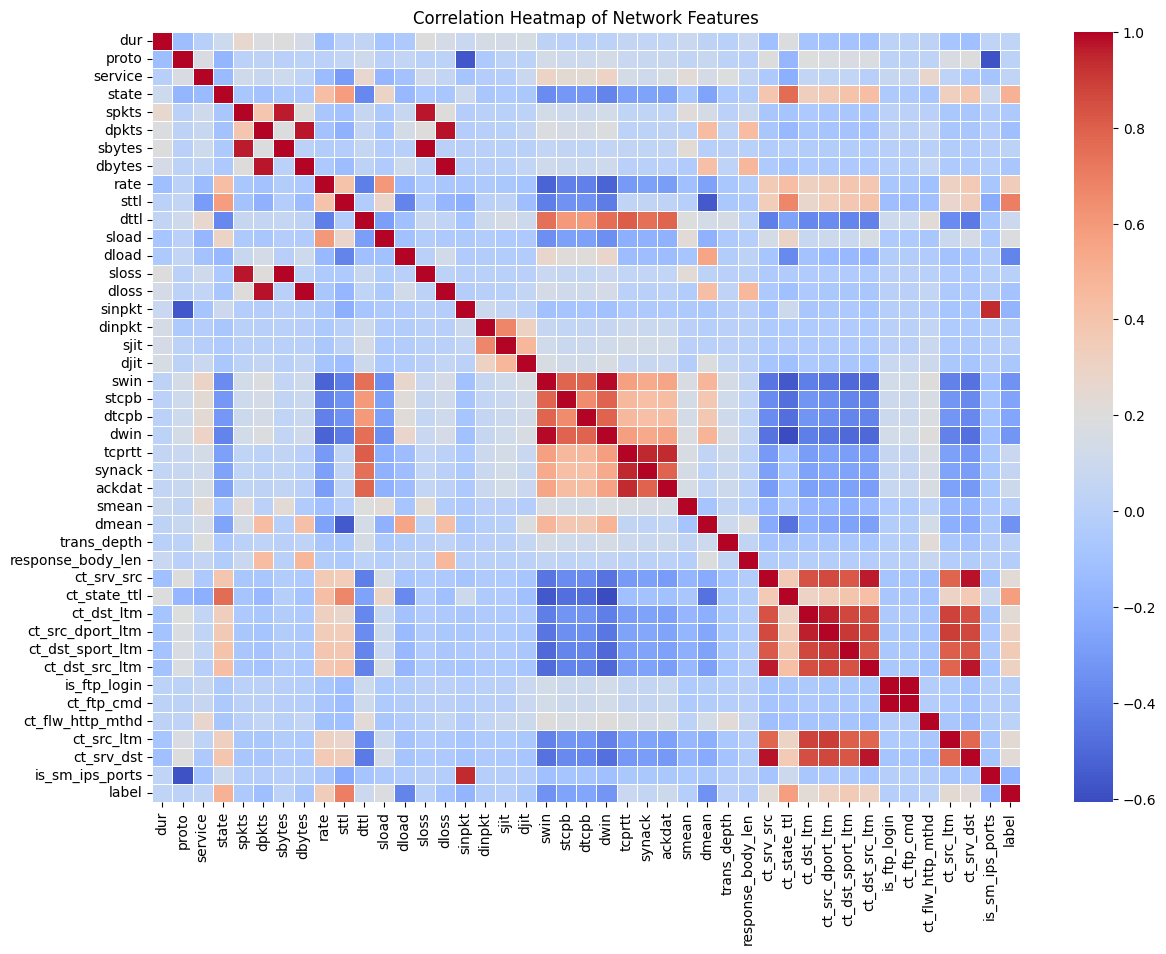

In [ ]:
# ==========================================================
# 8. Exploratory Data Analysis
# ==========================================================

# ------------------------------
# Boxplot Visualization
# ------------------------------

plt.figure(figsize=(15,6))

sns.boxplot(data=train_df.select_dtypes(include=np.number))

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")

plt.show()


# ------------------------------
# Correlation Heatmap
# ------------------------------

plt.figure(figsize=(14,10))

corr = train_df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Network Features")

plt.show()

In [ ]:
# ==========================================================
# 9. Feature Selection (Chi-Square)
# ==========================================================

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

selector = SelectKBest(score_func=chi2, k=20)

X_train_selected = selector.fit_transform(abs(X_train), y_train)

selected_features = X_train.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)


# Apply same selected features to test dataset
X_test = test_df[selected_features]
y_test = test_df['label']


Selected Features:
Index(['spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload',
       'dload', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'dmean', 'response_body_len'],
      dtype='object')


In [ ]:
# ==========================================================
# 10. Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_df[selected_features])
X_test_scaled  = scaler.transform(X_test)



In [ ]:
# ==========================================================
# Handle Class Imbalance using SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before balancing:")
print(y_train.value_counts())

print("After balancing:")
print(pd.Series(y_train_balanced).value_counts())

Before balancing:
label
1    119341
0     56000
Name: count, dtype: int64
After balancing:
label
0    119341
1    119341
Name: count, dtype: int64


In [ ]:
# ==========================================================
# PREPARE DATA FOR FEDERATED CLIENTS
# ==========================================================

train_data = pd.DataFrame(X_train_balanced, columns=selected_features)
train_data["label"] = y_train_balanced
print("Combined training data shape:", train_data.shape)


Combined training data shape: (238682, 21)


In [ ]:
# ==========================================================
#  CREATE FEDERATED CLIENTS
# ==========================================================

import numpy as np

def create_clients(data, num_clients=10):

    """
    Splits dataset into multiple client datasets
    """

    # Shuffle dataset
    data = data.sample(frac=1).reset_index(drop=True)

    # Split dataset into equal parts
    client_data = np.array_split(data, num_clients)

    clients = {}

    for i in range(num_clients):

        clients[f"client_{i+1}"] = client_data[i]

    return clients

    # Create 10 federated clients
clients = create_clients(train_data, num_clients=10)

print("Total clients:", len(clients))

# Check one client dataset
clients["client_1"].head()



Total clients: 10


/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,dloss,...,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,dmean,response_body_len,label
0,-0.133677,-0.172047,-0.050015,-0.103923,0.178922,0.723268,-0.720406,-0.113901,-0.277208,-0.131759,...,-0.089370,-0.110668,-0.148818,-0.915407,-0.715177,-0.715569,-0.906432,-0.480703,-0.039557,1
1,-0.075235,-0.081351,-0.046021,-0.075159,-0.576701,-1.141901,1.560002,-0.389941,-0.264547,-0.074868,...,0.011230,0.016610,1.674598,1.092456,0.149481,0.086654,1.103244,1.118112,-0.009690,1
2,-0.133677,-0.172047,-0.044522,-0.103923,0.094951,0.723268,-0.720406,2.120627,-0.277208,-0.131759,...,-0.089370,-0.110668,-0.148818,-0.915407,-0.715177,-0.715569,-0.906432,-0.480703,-0.039557,1
3,-0.075235,-0.099490,-0.047383,-0.101459,-0.576743,0.723268,1.560002,-0.389957,-0.276450,-0.112795,...,0.094421,0.076912,-0.079570,1.092456,1.976897,2.039448,1.103244,-0.310369,-0.039557,1
4,-0.075235,-0.099490,-0.047383,-0.101459,-0.576722,0.723268,1.560002,-0.389952,-0.276243,-0.112795,...,0.054077,0.054252,-0.097392,1.092456,-0.670270,0.917476,1.103244,-0.310369,-0.039557,1


In [ ]:
for client_name, data in clients.items():
    print(client_name, data.shape)


client_1 (23869, 21)
client_2 (23869, 21)
client_3 (23868, 21)
client_4 (23868, 21)
client_5 (23868, 21)
client_6 (23868, 21)
client_7 (23868, 21)
client_8 (23868, 21)
client_9 (23868, 21)
client_10 (23868, 21)


In [ ]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 11.7 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn

class CNN_IDS(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.conv1 = nn.Conv1d(1, 32, 3)
        self.pool = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(32, 64, 3)

        conv_output = ((input_size - 2)//2 - 2)//2 * 64

        self.fc1 = nn.Linear(conv_output, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):

        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))

        return x

In [ ]:
# ==========================================================
# DEFINE GLOBAL MODEL
# ==========================================================

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# def create_model(input_shape):

#     model = Sequential()

#     model.add(Conv1D(64, 3, activation='relu', input_shape=input_shape))
#     model.add(MaxPooling1D(2))

#     model.add(Conv1D(128, 3, activation='relu'))
#     model.add(MaxPooling1D(2))

#     model.add(Flatten())

#     model.add(Dense(128, activation='relu'))
#     model.add(Dropout(0.3))

#     model.add(Dense(1, activation='sigmoid'))

#     model.compile(
#         optimizer='adam',
#         loss='binary_crossentropy',
#         metrics=['accuracy']
#     )

#     return model


In [ ]:
# Input shape for CNN
global_model = CNN_IDS(len(selected_features))

print("Global PyTorch CNN model initialized")

Global PyTorch CNN model initialized


In [ ]:
# ==========================================================
# LOCAL CLIENT TRAINING
# ==========================================================

def train_client(client_data, global_model):

    X = client_data.drop(columns=["label"]).values
    y = client_data["label"].values

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    X = X.unsqueeze(1)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    model = CNN_IDS(X.shape[2])

    model.load_state_dict(global_model.state_dict())

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    criterion = nn.BCELoss()

    model.train()

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

    return model.state_dict()


In [ ]:
# ==========================================================
# LOCAL CLIENT TRAINING WITH DP
# ==========================================================

from opacus import PrivacyEngine
from torch.utils.data import TensorDataset, DataLoader

def train_client_with_dp(client_data, global_model):

    X = client_data.drop(columns=["label"]).values
    y = client_data["label"].values

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    X = X.unsqueeze(1)

    dataset = TensorDataset(X, y)

    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    model = CNN_IDS(X.shape[2])

    model.load_state_dict(global_model.state_dict())

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    privacy_engine = PrivacyEngine()

    model, optimizer, loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=loader,
        noise_multiplier=1.0,
        max_grad_norm=1.0,
    )

    criterion = nn.BCELoss()

    model.train()

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

    epsilon = privacy_engine.get_epsilon(delta=1e-5)

    print(f"Client ε = {epsilon:.2f}")

    return model.state_dict()

In [ ]:
from opacus import PrivacyEngine
from torch.utils.data import TensorDataset, DataLoader

def train_client_with_dp2(client_data, global_model, noise_multiplier):

    X = client_data.drop(columns=["label"]).values
    y = client_data["label"].values

    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    X = X.unsqueeze(1)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    model = CNN_IDS(X.shape[2])

    model.load_state_dict(global_model.state_dict())

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    privacy_engine = PrivacyEngine()

    model, optimizer, loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=loader,
        noise_multiplier=noise_multiplier,   # <-- now variable
        max_grad_norm=1.0,
    )

    criterion = nn.BCELoss()

    model.train()

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

    epsilon = privacy_engine.get_epsilon(delta=1e-5)

    print(f"Noise {noise_multiplier} → Client ε = {epsilon:.2f}")

    return model.state_dict()

In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test):

    model.eval()

    X_test = torch.tensor(X_test, dtype=torch.float32)
    X_test = X_test.unsqueeze(1)

    with torch.no_grad():

        outputs = model(X_test).squeeze()

        probs = outputs.numpy()

    preds = (probs > 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    return acc, precision, recall, f1

In [ ]:
# Metrics without DP
accuracy_no_dp = []
precision_no_dp = []
recall_no_dp = []
f1_no_dp = []

# Metrics with DP
accuracy_dp = []
precision_dp = []
recall_dp = []
f1_dp = []

In [ ]:
# ==========================================================
#  FEDERATED TRAINING LOOP (WITHOUT DP)
# ==========================================================

num_rounds = 5

print("\n================ TRAINING WITHOUT DP ================")

# Initialize global model (PyTorch)
global_model = CNN_IDS(len(selected_features))

for round_num in range(num_rounds):

    print(f"\n========= Federated Round {round_num+1} =========")

    client_weights = []

    # Train each client
    for client_name, client_data in clients.items():

        print("Training", client_name)

        weights = train_client(client_data, global_model)   # no DP

        client_weights.append(weights)

    # ======================================================
    # Federated Averaging (PyTorch)
    # ======================================================

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack(
            [client_weights[i][key] for i in range(len(client_weights))]
        ).mean(0)

    global_model.load_state_dict(global_dict)

    # ======================================================
    # Evaluation
    # ======================================================

    acc, precision, recall, f1 = evaluate_model(
        global_model,
        X_test_scaled,
        y_test
    )

    print("\nGlobal Model Performance (No DP)")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    accuracy_no_dp.append(acc)
    precision_no_dp.append(precision)
    recall_no_dp.append(recall)
    f1_no_dp.append(f1)

print("\nFederated training completed (No DP)")


================ TRAINING WITHOUT DP ================

========= Federated Round 1 =========
Training client_1
Training client_2
Training client_3
Training client_4
Training client_5
Training client_6
Training client_7
Training client_8
Training client_9
Training client_10

Global Model Performance (No DP)
Accuracy  : 0.7856
Precision : 0.7224
Recall    : 0.9914
F1 Score  : 0.8358

========= Federated Round 2 =========
Training client_1
Training client_2
Training client_3
Training client_4
Training client_5
Training client_6
Training client_7
Training client_8
Training client_9
Training client_10

Global Model Performance (No DP)
Accuracy  : 0.7888
Precision : 0.7259
Recall    : 0.9904
F1 Score  : 0.8378

========= Federated Round 3 =========
Training client_1
Training client_2
Training client_3
Training client_4
Training client_5
Training client_6
Training client_7
Training client_8
Training client_9
Training client_10

Global Model Performance (No DP)
Accuracy  : 0.7945
Precision : 

In [ ]:
# ==========================================================
#  FEDERATED TRAINING LOOP (WITH DP)
# ==========================================================

print("\n================ TRAINING WITH DP ================")

# Reinitialize global model
global_model = CNN_IDS(len(selected_features))

for round_num in range(num_rounds):

    print(f"\n========= Federated Round {round_num+1} =========")

    client_weights = []

    # Train each client with DP
    for client_name, client_data in clients.items():

        print("Training", client_name)

        weights = train_client_with_dp(client_data, global_model)

        client_weights.append(weights)

    # Federated Averaging (safe version)

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

       client_tensors = []

       for client in client_weights:

          if key in client:
             client_tensors.append(client[key])

          elif "_module." + key in client:
             client_tensors.append(client["_module." + key])

       global_dict[key] = torch.stack(client_tensors).mean(0)

    global_model.load_state_dict(global_dict)

    # ======================================================
    # Evaluation
    # ======================================================

    acc, precision, recall, f1 = evaluate_model(
        global_model,
        X_test_scaled,
        y_test
    )

    print("\nGlobal Model Performance (With DP)")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    accuracy_dp.append(acc)
    precision_dp.append(precision)
    recall_dp.append(recall)
    f1_dp.append(f1)

print("\nFederated training completed (With DP)")


================ TRAINING WITH DP ================

========= Federated Round 1 =========
Training client_1


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_5819/1470389165.py:50: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Client ε = 0.29
Training client_2


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_5819/1470389165.py:50: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Client ε = 0.29
Training client_3


...

Client ε = 0.29
Training client_9


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_5819/1470389165.py:50: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Client ε = 0.29
Training client_10


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_5819/1470389165.py:50: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Client ε = 0.29

Global Model Performance (With DP)
Accuracy  : 0.7726
Precision : 0.7090
Recall    : 0.9957
F1 Score  : 0.8282

Federated training completed (With DP)


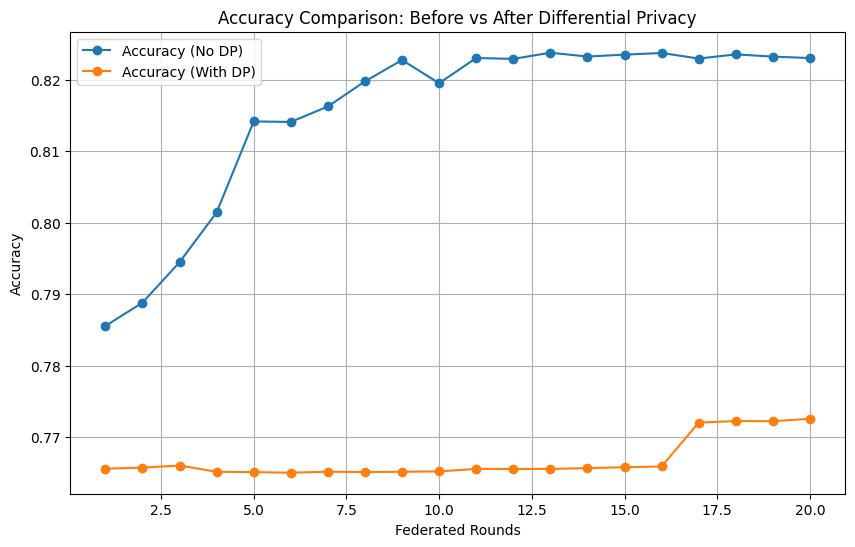

In [ ]:
import matplotlib.pyplot as plt

rounds = range(1, num_rounds + 1)

plt.figure(figsize=(10,6))

plt.plot(rounds, accuracy_no_dp, marker='o', label="Accuracy (No DP)")
plt.plot(rounds, accuracy_dp, marker='o', label="Accuracy (With DP)")

plt.xlabel("Federated Rounds")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Before vs After Differential Privacy")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
noise_levels = [0.0, 0.5, 1.0, 1.5, 2.0]
accuracy_noise = []

In [ ]:
for noise in noise_levels:

    print(f"\nTraining with noise = {noise}")

    global_model = CNN_IDS(len(selected_features))

    for round_num in range(num_rounds):

        client_weights = []

        for client_name, client_data in clients.items():

            if noise == 0.0:
                weights = train_client(client_data, global_model)

            else:
                weights = train_client_with_dp2(client_data, global_model, noise)

            client_weights.append(weights)

        # Federated Averaging
        global_dict = global_model.state_dict()

        for key in global_dict.keys():

           client_tensors = []

           for client in client_weights:

               if key in client:
                 client_tensors.append(client[key])

               elif "_module." + key in client:
                 client_tensors.append(client["_module." + key])

           global_dict[key] = torch.stack(client_tensors).mean(0)

        global_model.load_state_dict(global_dict)

    acc, precision, recall, f1 = evaluate_model(
        global_model,
        X_test_scaled,
        y_test
    )

    accuracy_noise.append(acc)

    print(f"Noise {noise} → Accuracy {acc:.4f}")


Training with noise = 0.0
Noise 0.0 → Accuracy 0.8237

Training with noise = 0.5


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_5819/1757488192.py:45: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Noise 0.5 → Client ε = 4.40


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_5819/1757488192.py:45: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Noise 0.5 → Client ε = 4.40


...

Noise 2.0 → Client ε = 0.10


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_5819/1757488192.py:45: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Noise 2.0 → Client ε = 0.10


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_5819/1757488192.py:45: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Noise 2.0 → Client ε = 0.10
Noise 2.0 → Accuracy 0.7651


In [ ]:
print(len(noise_levels), len(accuracy_noise))

5 7


In [ ]:
accuracy_noise = accuracy_noise[:len(noise_levels)]

In [ ]:
print("Noise values:", noise_levels)
print("Accuracy values:", accuracy_noise)
print(len(noise_levels), len(accuracy_noise))

Noise values: [0.0, 0.5, 1.0, 1.5, 2.0]
Accuracy values: [0.8249647767575183, 0.8242238740708352, 0.8237258902978186, 0.7847252587086431, 0.7824661128115435]
5 5


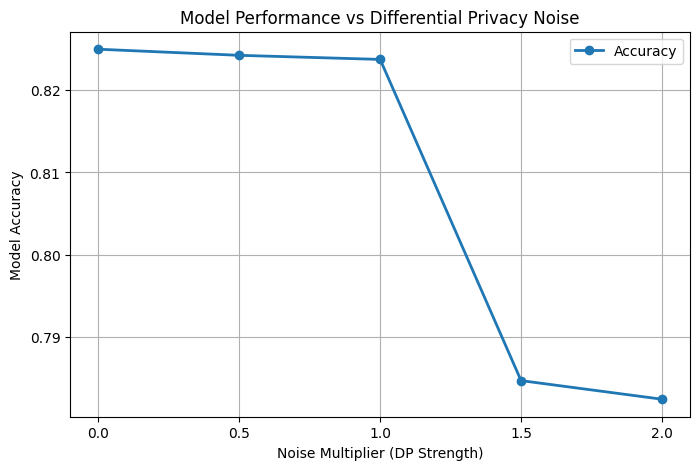

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(noise_levels, accuracy_noise, marker='o', linewidth=2, label="Accuracy")

plt.xlabel("Noise Multiplier (DP Strength)")
plt.ylabel("Model Accuracy")
plt.title("Model Performance vs Differential Privacy Noise")

plt.xticks(noise_levels)
plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# STEP 8: TEST GLOBAL FEDERATED MODEL
# ==========================================================

X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

y_pred = (global_model.predict(X_test_cnn) > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Federated CNN Results")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


2573/2573 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
Federated CNN Results
Accuracy: 0.8171913715201866
Precision: 0.7582865623773861
Recall: 0.9805435453983941
F1 Score: 0.8552106280843859


In [ ]:
# ==========================================================
# 12. Machine Learning Models
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():

    model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print()

    results.append([name, acc, prec, rec, f1])


# ==========================================================
# 13. CNN Model
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Reshape for CNN
X_train_cnn = X_train_balanced.reshape(
    X_train_balanced.shape[0],
    X_train_balanced.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

cnn_model = Sequential()

cnn_model.add(Conv1D(64, 3, activation='relu', input_shape=(X_train_cnn.shape[1],1)))
cnn_model.add(MaxPooling1D(2))

cnn_model.add(Conv1D(128, 3, activation='relu'))
cnn_model.add(MaxPooling1D(2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.3))

cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    X_train_cnn,
    y_train_balanced,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

# Prediction
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred_cnn)
prec = precision_score(y_test, y_pred_cnn)
rec  = recall_score(y_test, y_pred_cnn)
f1   = f1_score(y_test, y_pred_cnn)

print("CNN Results")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

results.append(["CNN", acc, prec, rec, f1])


# ==========================================================
# Confusion Matrices
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Logistic Regression
cm_lr = confusion_matrix(y_test, models["Logistic Regression"].predict(X_test_scaled))

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, models["Random Forest"].predict(X_test_scaled))

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==========================================================
# Model Comparison Table
# ==========================================================

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

print(results_df)



In [ ]:
# ==========================================================
# 14. Model Comparison Table
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

print(results_df)


In [ ]:

# ==========================================================
# 16. Gradient Boosting Model
# ==========================================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred_gb)
prec = precision_score(y_test, y_pred_gb)
rec  = recall_score(y_test, y_pred_gb)
f1   = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print(acc, prec, rec, f1)

results.append(["Gradient Boosting", acc, prec, rec, f1])

In [ ]:
# ==========================================================
# 17. XGBoost Model
# ==========================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb)
rec  = recall_score(y_test, y_pred_xgb)
f1   = f1_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(acc, prec, rec, f1)

results.append(["XGBoost", acc, prec, rec, f1])

# =========================================
# Confusion Matrix - XGBoost
# =========================================

from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - XGBoost")

plt.show()